# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

In [ ]:
!curl -O https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4463k  100 4463k    0     0  9196k      0 --:--:-- --:--:-- --:--:-- 9203k


Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv("travel%20insurance.csv")
print(dataset.head(), '\n')
print(dataset.isnull().sum())

  Agency    Agency Type Distribution Channel                     Product Name  \
0    CBH  Travel Agency              Offline               Comprehensive Plan   
1    CBH  Travel Agency              Offline               Comprehensive Plan   
2    CWT  Travel Agency               Online  Rental Vehicle Excess Insurance   
3    CWT  Travel Agency               Online  Rental Vehicle Excess Insurance   
4    CWT  Travel Agency               Online  Rental Vehicle Excess Insurance   

  Claim  Duration Destination  Net Sales  Commision (in value) Gender  Age  
0    No       186    MALAYSIA      -29.0                  9.57      F   81  
1    No       186    MALAYSIA      -29.0                  9.57      F   71  
2    No        65   AUSTRALIA      -49.5                 29.70    NaN   32  
3    No        60   AUSTRALIA      -39.6                 23.76    NaN   32  
4    No        79       ITALY      -19.8                 11.88    NaN   41   

Agency                      0
Agency Type        

In [ ]:
''' Здесь мы видим, что только столбец с Gender содержит пустые значения.
    Узнаем как влияет данный столбец на Claim
'''

cross_data = pd.crosstab(dataset["Gender"].fillna("Unknown"), dataset["Claim"],
                         normalize=True)

cross_data

Claim,No,Yes
Gender,,
F,0.134637,0.005464
M,0.142974,0.004627
Unknown,0.707750,0.004548


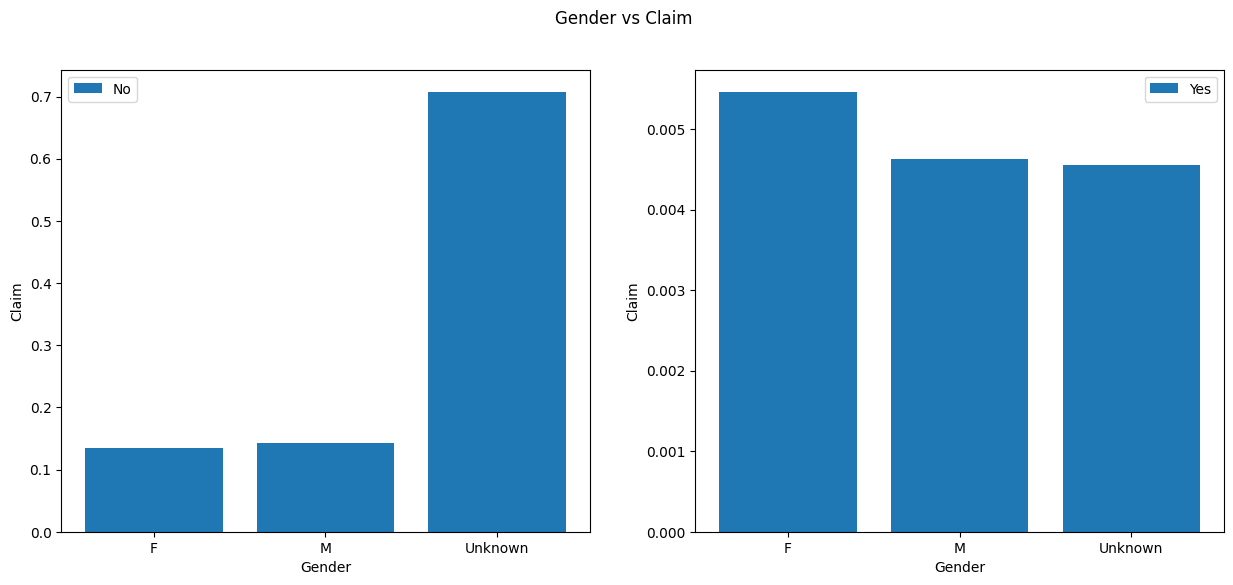

In [ ]:
fig_net, ax_net = plt.subplots(1, 2, figsize=(15, 6))
fig_net.suptitle('Gender vs Claim')

ax_net[0].bar(cross_data.index, cross_data["No"], label='No')
# люди которым отказали
ax_net[0].set_xlabel('Gender')
ax_net[0].set_ylabel('Claim')
ax_net[0].legend()

ax_net[1].bar(cross_data.index, cross_data["Yes"], label='Yes')
# люди которым одобрили
ax_net[1].set_xlabel('Gender')
ax_net[1].set_ylabel('Claim')
ax_net[1].legend()

plt.show()

In [ ]:
''' Здесь мы видим, что Male и Female, имеют примерно одинаковое распределение.
    Мы не можем судить об Unknown, но здесь отсутствуют больше 70% данных
    поэтому данный столбец можно удалить
'''
dataset.drop(columns=["Gender"], inplace=True)

In [ ]:
def onehot_encoding(x: np.ndarray) -> np.ndarray:
    encoding_res = list()
    for col in range(x.shape[1]):
        unique_cnt = np.unique(x[:,col])
        encoding = np.zeros((len(x[:, col]), len(unique_cnt)), dtype="int")
        compression = dict()
        for id, i in enumerate(unique_cnt):
            compression[i] = id
        for id, category in enumerate(x[:, col]):
            encoding[id, compression[category]] = 1
        encoding_res.append(encoding)
    return np.hstack(encoding_res)

In [ ]:
def minmax_scale(X: np.ndarray) -> np.ndarray:
    x_min = np.min(X, axis=0, keepdims=True)
    x_max = np.max(X, axis=0, keepdims=True)
    d = x_max - x_min
    d[d == 0] = 1
    return (X - x_min) / d

In [ ]:
cat_features_mask = (dataset.dtypes == "object").values
# преобразуем категориальные признаки в бинарные

encoding = onehot_encoding(dataset[dataset.columns[cat_features_mask]].values)

print(encoding.shape)


(63326, 197)


In [ ]:
# масштабируем числовые признаки
scaled_data = minmax_scale(dataset[dataset.columns[~cat_features_mask]].values)

print(scaled_data)

dataset.shape

[[0.03850092 0.30025021 0.03375661 0.68644068]
 [0.03850092 0.30025021 0.03375661 0.60169492]
 [0.01372107 0.28315263 0.1047619  0.27118644]
 ...
 [0.00081917 0.33944954 0.02222222 0.48305085]
 [0.00102396 0.33944954 0.02222222 0.53389831]
 [0.00491501 0.34612177 0.03209877 0.29661017]]


(63326, 10)

Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели.

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

In [ ]:
Q1 = dataset[dataset.columns[~cat_features_mask]].quantile(0.25)
Q3 = dataset[dataset.columns[~cat_features_mask]].quantile(0.75)
IQR = Q3 - Q1
lb = Q1 - 1.5 * IQR
ub = Q3 + 1.5 * IQR
outliers = (dataset[dataset.columns[~cat_features_mask]] < lb) | (dataset[dataset.columns[~cat_features_mask]] > ub)
# нахожу все выбросы
dataset = dataset[~outliers.any(axis=1)]
# удаляю все строки где есть выбросы
print(dataset.shape)

(45598, 10)


In [ ]:
dataset["Agency_Combined"] = dataset["Agency"] + "_" + dataset["Agency Type"]
# объединим данные чтобы избавиться от зависимостей
dataset.drop(columns=["Agency", "Agency Type"], inplace=True)

In [ ]:
'''Оставляем только топ 20 самых частых значений для каждого признака,
остальные заменяем на other '''

top_products = dataset['Product Name'].value_counts().index[:20]
dataset['Product Name'] = dataset['Product Name'].apply(lambda x: x if x in top_products else 'Other')

top_destinations = dataset['Destination'].value_counts().index[:20]
dataset['Destination'] = dataset['Destination'].apply(lambda x: x if x in top_destinations else 'Other')

top_agencies = dataset['Agency_Combined'].value_counts().index[:20]
dataset['Agency_Combined'] = dataset['Agency_Combined'].apply(lambda x: x if x in top_agencies else 'Other')

dataset.shape

(45598, 9)

In [ ]:
dataset["Claim"].value_counts(normalize=True) * 100
dataset.head()

,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Age,Agency_Combined
4,Online,Rental Vehicle Excess Insurance,No,79,Other,-19.8,11.88,41,CWT_Travel Agency
8,Online,Rental Vehicle Excess Insurance,No,57,THAILAND,-19.8,11.88,44,CWT_Travel Agency
11,Online,Basic Plan,No,1,MALAYSIA,-18.0,6.30,47,JZI_Airlines
14,Online,2 way Comprehensive Plan,No,39,VIET NAM,-25.0,0.00,36,EPX_Travel Agency
15,Online,Rental Vehicle Excess Insurance,No,6,Other,-19.8,11.88,53,CWT_Travel Agency


In [ ]:
# Уменьшим частый класс No, в соотношении 1:2
majority = dataset[dataset["Claim"] == "No"]
minority = dataset[dataset["Claim"] == "Yes"]

sample = majority.sample(n=len(minority) * 2, random_state=15)
dataset = pd.concat([sample, minority])
print(dataset.shape, dataset["Claim"].value_counts(normalize=True) * 100)

(1464, 9) Claim
No     66.666667
Yes    33.333333
Name: proportion, dtype: float64


In [ ]:
dataset_features = dataset.drop(columns=["Claim"])

cat_features_mask = (dataset_features.dtypes == "object").values


print(dataset_features[dataset_features.columns[cat_features_mask]].values)

encoded_data = onehot_encoding(dataset_features[dataset_features.columns[cat_features_mask]].values)
scaled_data = minmax_scale(dataset_features[dataset_features.columns[~cat_features_mask]].values)

print(encoded_data.shape)
print(scaled_data.shape)

[['Online' '1 way Comprehensive Plan' 'KOREA, REPUBLIC OF'
  'EPX_Travel Agency']
 ['Online' '2 way Comprehensive Plan' 'TAIWAN, PROVINCE OF CHINA'
  'EPX_Travel Agency']
 ['Online' '2 way Comprehensive Plan' 'SINGAPORE' 'EPX_Travel Agency']
 ...
 ['Online' 'Bronze Plan' 'SINGAPORE' 'C2B_Airlines']
 ['Online' 'Bronze Plan' 'SINGAPORE' 'C2B_Airlines']
 ['Online' 'Bronze Plan' 'SINGAPORE' 'C2B_Airlines']]
(1464, 52)
(1464, 4)


In [ ]:
# объединим данные
final_data = np.hstack((scaled_data, encoded_data))

print(final_data)

final_data = pd.DataFrame(final_data)
print(final_data.head(1))

[[0.03418803 0.29126214 0.         ... 0.         0.         0.        ]
 [0.05982906 0.50485437 0.         ... 0.         0.         0.        ]
 [0.52991453 0.33980583 0.         ... 0.         0.         0.        ]
 ...
 [0.05128205 0.29126214 0.1754386  ... 0.         0.         0.        ]
 [0.22222222 0.67961165 0.52631579 ... 0.         0.         0.        ]
 [0.09401709 0.30097087 0.18421053 ... 0.         0.         0.        ]]
         0         1    2        3    4    5    6    7    8    9   ...   46  \
0  0.034188  0.291262  0.0  0.28125  0.0  1.0  1.0  0.0  0.0  0.0  ...  0.0   

    47   48   49   50   51   52   53   54   55  
0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  

[1 rows x 56 columns]


final_data - обучающая выборка

### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

In [ ]:
# разделение на test/train
from sklearn.model_selection import train_test_split

X = final_data
y = np.where(dataset['Claim'] == 'Yes', 1, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=47)



In [ ]:
def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2.

In [ ]:
# посчитайте аналитическое решение

w = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
y_pred = X_test @ w
# получим классификацию
y_pred_yes_no = np.where(y_pred >= 0.5, 1, 0)

accuracy_s = accuracy(y_test, y_pred_yes_no)
print(f"Accuracy: {accuracy_s:.4f}")


Accuracy: 0.6212


In [ ]:
# посчитать аналитическое решение с регуляризацией
w_reg = np.linalg.inv(X_train.T @ X_train + 1 * np.eye(X_train.shape[1])) @ X_train.T @ y_train
y_pred = X_test @ w_reg
# получим классификацию
y_pred_yes_no = np.where(y_pred >= 0.5, 1, 0)

accuracy_s = accuracy(y_test, y_pred_yes_no)
print(f"Accuracy: {accuracy_s:.4f}")

Accuracy: 0.7952


Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [ ]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# посчитайте MSE, предварительно округлив предсказанные ответы до целого
y_pred_yes_no = np.where(y_pred >= 0.5, 1, 0)
print(f"MSE: {mean_squared_error(y_test, y_pred_yes_no):.4f}")

MSE: 0.2082


### Вывод (1 балла)

Напишите краткий вывод по заданию (достаточно пары предложений). Расскажите, какие способы предобработки данных вы выбрали и почему. Насколько хороша ваша модель?

Сначала я удалил столбец - Gender с пропущенными значениями (около 70%), так как он не содержал полезной информации. Затем заметил, что большое количество категориальных переменных, преобразованных с помощью one-hot encoding, существенно увеличивает размерность данных (примерно 200 столбцов). Следуя рекомендациям, я удалил записи с выбросами, используя метод межквартильного размаха.

При обучении модели возникала ошибка, связанная с мультиколлинеарностью. Первоначально для снижения размерности я оставил только 20 наиболее частых подкатегорий, что позволило уменьшить количество столбцов, получаемых после one-hot encoding. Однако проблема оставалась из-за зависимости между переменными Agency и Agency Type. Вместо удаления данных переменных я решил их объединить, что позволило устранить указанную проблему.

Кроме того, датасет был несбалансирован – количество записей с Claim = No значительно превышало количество записей с Claim = Yes. Для корректировки этого дисбаланса я сделал downsampling в соотношении 1:2, что привело к распределению 66% для No и 33% для Yes. После я исключил переменную Claim из обучающей выборки, затем данные были закодированы и объединены с применением minmax_scaler.

В результате модель показывает неплохие результаты при использовании L2-регуляризации, тогда как без неё результаты значительно хуже, что указывает на наличие остающихся зависимостей между переменными.

---